## Predicting laptop pricing using random forest regression
for better optimisation and lower RMSE

In [ ]:
# =========================
# STEP 3 — BETTER REGRESSION (NON-LINEAR)
# =========================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# -------------------------
# LOAD + CLEAN
# -------------------------
sales = pd.read_csv("lap_sales.csv")

sales = sales.rename(columns={
    "Price_euros": "price",
    "Ram..GB.": "ram",
    "Memory..GB.": "storage",
    "Weight..Kg.": "weight",
    "Cpu.Speed..GHz.": "cpu_speed"
})

sales = sales[[
    "price",
    "Company",
    "TypeName",
    "Cpu.Series",
    "ram",
    "storage",
    "Inches",
    "weight",
    "cpu_speed"
]].dropna()


# -------------------------
# ENCODE CATEGORICALS
# (trees handle dummies well)
# -------------------------
sales = pd.get_dummies(
    sales,
    columns=["Company","TypeName","Cpu.Series"],
    drop_first=True
)


# -------------------------
# SPLIT
# -------------------------
X = sales.drop("price", axis=1)
y = sales["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -------------------------
# RANDOM FOREST MODEL
# -------------------------
model = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    min_samples_split=3,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

pred = model.predict(X_test)


# -------------------------
# METRICS
# -------------------------
r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mape = np.mean(np.abs((y_test - pred) / y_test)) * 100

# Adjusted R²
n = len(y_test)
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)


print("R²:", round(r2,3))
print("Adjusted R²:", round(adj_r2,3))
print("RMSE (€):", round(rmse,2))
print("MAPE (% error):", round(mape,2))

# -------------------------
# FEATURE IMPORTANCE
# (helps explain price drivers)
# -------------------------
importances = pd.Series(model.feature_importances_, index=X.columns)
print("\nTop price drivers:\n")
print(importances.sort_values(ascending=False).head(10))

R²: 0.79
Adjusted R²: 0.697
RMSE (€): 246.17
MAPE (% error): 17.07

Top price drivers:

ram                   0.613099
weight                0.137421
cpu_speed             0.052849
Company_Razer         0.043259
storage               0.036557
Inches                0.029813
Cpu.Series_i5         0.020785
TypeName_Notebook     0.014356
Company_Lenovo        0.007272
TypeName_Ultrabook    0.007064
dtype: float64


In [ ]:
# checking for overfitting

from sklearn.model_selection import cross_val_score

cv_r2 = cross_val_score(model, X, y, cv=5, scoring="r2").mean()
print("CV R²:", round(cv_r2,3))

CV R²: 0.785



Predicted Prices by Segment

          Segment  Predicted Price (€)
0  Basic/Portable              1491.38
1         Premium              2324.08
2           Power              2206.31
3     Reliability               897.25


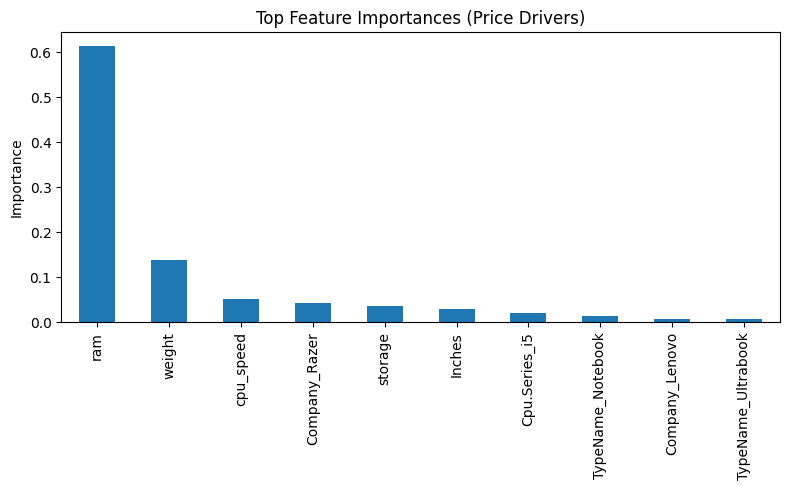

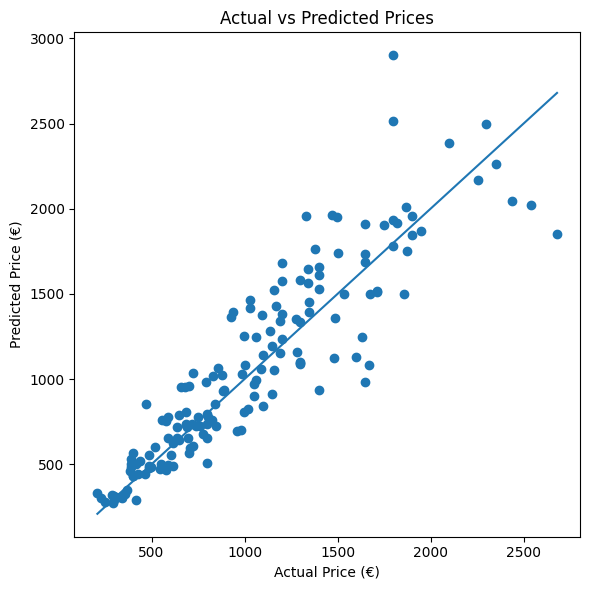

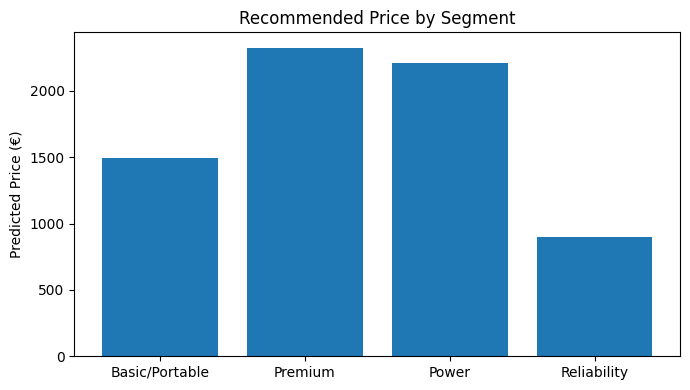

In [ ]:
# =========================
# SEGMENT PRICE PREDICTION + VISUALS
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. CREATE SEGMENT CONFIGS (same features as model)
# -------------------------------------------------

segment_configs = pd.DataFrame([
    # Segment 1 – Basic / Portable
    {
        "ram": 8,
        "storage": 256,
        "Inches": 13.5,
        "weight": 1.3,
        "cpu_speed": 2.3
    },

    # Segment 2 – Premium
    {
        "ram": 16,
        "storage": 512,
        "Inches": 14,
        "weight": 1.3,
        "cpu_speed": 3.0
    },

    # Segment 3 – Power
    {
        "ram": 16,
        "storage": 512,
        "Inches": 15.6,
        "weight": 2.5,
        "cpu_speed": 3.2
    },

    # Segment 4 – Reliability
    {
        "ram": 8,
        "storage": 256,
        "Inches": 14,
        "weight": 1.8,
        "cpu_speed": 2.0
    }
])

# align columns with training data
segment_configs = segment_configs.reindex(columns=X.columns, fill_value=0)

# predict
segment_prices = model.predict(segment_configs)

segment_names = [
    "Basic/Portable",
    "Premium",
    "Power",
    "Reliability"
]

summary = pd.DataFrame({
    "Segment": segment_names,
    "Predicted Price (€)": np.round(segment_prices, 2)
})

print("\nPredicted Prices by Segment\n")
print(summary)



# -------------------------------------------------
# 2. FEATURE IMPORTANCE (GLOBAL)
# -------------------------------------------------

importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
importances.plot(kind="bar")
plt.title("Top Feature Importances (Price Drivers)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()



# -------------------------------------------------
# 3. ACTUAL vs PREDICTED SCATTER
# -------------------------------------------------

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual Price (€)")
plt.ylabel("Predicted Price (€)")
plt.title("Actual vs Predicted Prices")
plt.tight_layout()
plt.show()



# -------------------------------------------------
# 4. SEGMENT PRICE COMPARISON BAR CHART
# -------------------------------------------------

plt.figure(figsize=(7,4))
plt.bar(summary["Segment"], summary["Predicted Price (€)"])
plt.ylabel("Predicted Price (€)")
plt.title("Recommended Price by Segment")
plt.tight_layout()
plt.show()